In [3]:
# %pip install --upgrade google-cloud-bigquery 
# Install the BigQuery client library.

   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.9 MB 1.9 MB/s eta 0:00:03
   ----------------- ---------------------- 2.1/4.9 MB 4.9 MB/s eta 0:00:01
   -------------------------------------- - 4.7/4.9 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 4.9/4.9 MB 7.3 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------  3.4/3.5 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 14.8 MB/s  0:00:00

   ----------------------------------------  0/15 [pyasn1]
   ----------------------------------------  0/15 [pyasn1]
   -- -------------------------------------  1/15 [protobuf]
   -- -------------------------------------  1/15 [protobuf]
   -- -------------------------------------  1/15 [protobuf]
   -- -------------------------------------  1/15 [protobuf]
   -- -------------------------------------  1/

In [4]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Import required libraries
from google.cloud import bigquery

# Initialize the BigQuery client
client = bigquery.Client(project="customer-chrun-project")

# Define the SQL query to pull your feature engineering matrix
query = """
    WITH cte_latest_subs AS (
        SELECT account_id, subscription_id, ROW_NUMBER() OVER(PARTITION BY account_id ORDER BY start_date DESC) as latest_subscription_id
        FROM `customer-chrun-project.ravenstack_analytics.subscriptions`
    ),
    cte_features AS (
        SELECT subscription_id, count(usage_id) as total_usage_events, max(usage_date) as last_usage_date
        FROM `customer-chrun-project.ravenstack_analytics.feature_usage`
        GROUP BY subscription_id
    ),
    cte_support AS (
        SELECT account_id, count(ticket_id) as total_tickets, ROUND(COALESCE(avg(satisfaction_score), 0), 2) as avg_satisfaction_score
        FROM `customer-chrun-project.ravenstack_analytics.support_tickets`
        GROUP BY account_id
    ),
    cte_churn AS (
        SELECT DISTINCT account_id
        FROM `customer-chrun-project.ravenstack_analytics.churn_events`
    )
    SELECT
        a.account_id,
        s.subscription_id,
        f.total_usage_events,
        f.last_usage_date,
        t.total_tickets,
        t.avg_satisfaction_score,
        CASE WHEN c.account_id IS NOT NULL THEN 1 ELSE 0 END AS churn_target
    FROM `customer-chrun-project.ravenstack_analytics.accounts` a
    LEFT JOIN cte_latest_subs s ON a.account_id = s.account_id AND s.latest_subscription_id = 1
    LEFT JOIN cte_features f ON s.subscription_id = f.subscription_id
    LEFT JOIN cte_support t ON a.account_id = t.account_id
    LEFT JOIN cte_churn c ON a.account_id = c.account_id
"""

# Execute the query and load the results directly into a Pandas DataFrame
df = client.query(query).to_dataframe()

# Display the first 5 rows and the shape of the dataset to verify
print(f"Dataset Shape: {df.shape}")
display(df.head())

c:\Users\SAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\auth\_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\SAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset Shape: (500, 7)


,account_id,subscription_id,total_usage_events,last_usage_date,total_tickets,avg_satisfaction_score,churn_target
0,A-1b707d,S-47985c,2,2024-11-01,3,0.00,1
1,A-fd7ad3,S-4f43fd,6,2024-11-20,8,4.17,1
2,A-443b7c,S-1e83a6,3,2024-12-27,8,4.40,0
3,A-89ee83,S-bf304b,3,2024-05-17,5,4.00,0
4,A-e19ff6,S-d90f0a,2,2023-08-03,3,4.67,1


In [12]:
# 1. Check for missing values (Validating our SQL COALESCE logic)
print("--- Missing Values Check ---")
display(df.isnull().sum())

# 2. Check Class Imbalance
print("\n--- Churn Class Distribution ---")
churn_distribution = df['churn_target'].value_counts(normalize=True) * 100
display(churn_distribution.round(2).astype(str) + '%')

--- Missing Values Check ---


account_id                0
subscription_id           0
total_usage_events        4
last_usage_date           4
total_tickets             8
avg_satisfaction_score    8
churn_target              0
dtype: int64


--- Churn Class Distribution ---


churn_target
1    70.4%
0    29.6%
Name: proportion, dtype: object

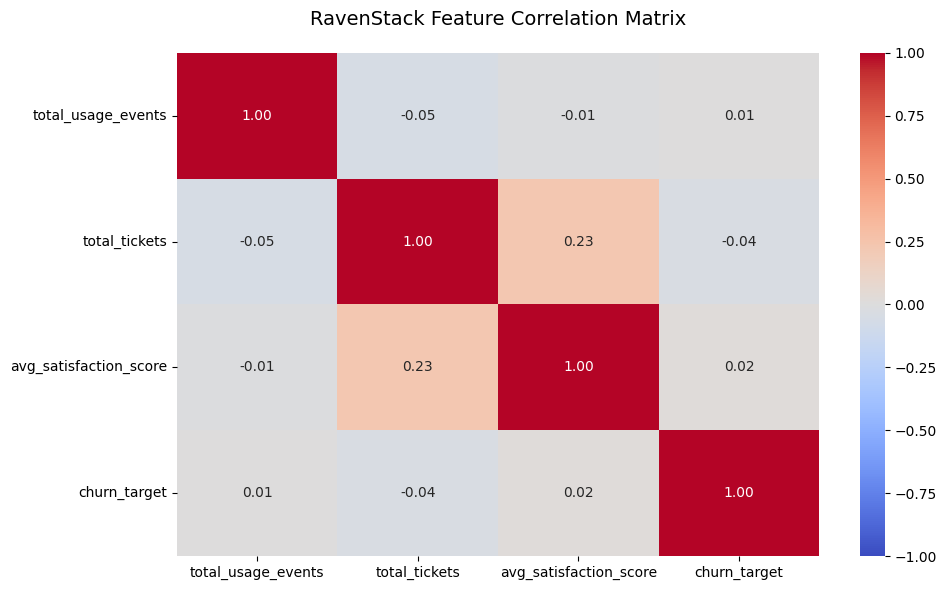

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Generate the Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, vmin=-1, vmax=1)
plt.title("RavenStack Feature Correlation Matrix", pad=20, fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Import ML libraries
from sklearn.model_selection import train_test_split
import pandas as pd

print("--- Starting Preprocessing ---")

# 1. Date Feature Engineering
# Convert date to datetime and extract predictive numerical features
df['last_usage_date'] = pd.to_datetime(df['last_usage_date'])
df['last_usage_year'] = df['last_usage_date'].dt.year
df['last_usage_month'] = df['last_usage_date'].dt.month
df['last_usage_day'] = df['last_usage_date'].dt.day
df['last_usage_weekday'] = df['last_usage_date'].dt.weekday

# 2. Define Features (X) and Target (y)
# Drop IDs (they hold no predictive value) and the original date column
X = df.drop(columns=['account_id', 'subscription_id', 'churn_target', 'last_usage_date'])
y = df['churn_target']

# 3. Handle Categorical Variables
# Convert any remaining text columns into 1s and 0s (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

--- Starting Preprocessing ---
Training Features Shape: (400, 7)
Testing Features Shape: (100, 7)


In [19]:
from xgboost import XGBClassifier

print("--- Training XGBoost Model ---")

# 1. Handle Class Imbalance mathematically
negative_class = (y_train == 0).sum()
positive_class = (y_train == 1).sum()

# Calculate the optimal weight for the minority class
scale_weight = negative_class / positive_class
print(f"Calculated scale_pos_weight: {scale_weight:.2f}")

# 2. Initialize the XGBoost Model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_weight,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

# 3. Train the Model
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

--- Training XGBoost Model ---
Calculated scale_pos_weight: 0.42
XGBoost model training complete.


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Model Evaluation ---")

# Generate predictions on the unseen test data
y_pred = xgb_model.predict(X_test)

# Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Evaluation ---
Confusion Matrix:
[[11 19]
 [25 45]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.31      0.37      0.33        30
         1.0       0.70      0.64      0.67        70

    accuracy                           0.56       100
   macro avg       0.50      0.50      0.50       100
weighted avg       0.58      0.56      0.57       100



--- Explainable AI (SHAP) ---


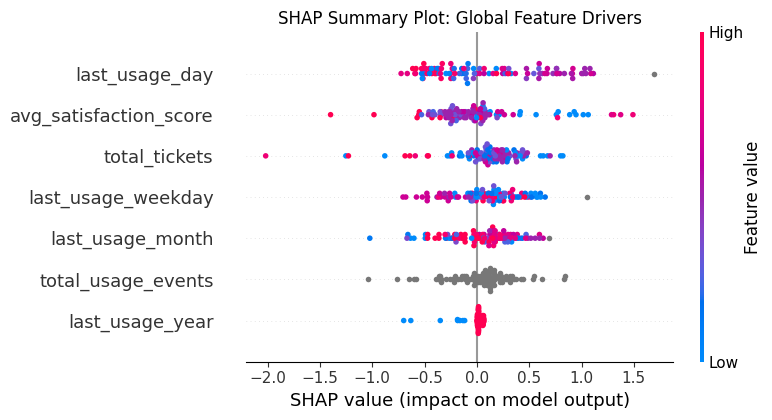


Generating Local Explanation for Test Customer Index: 0


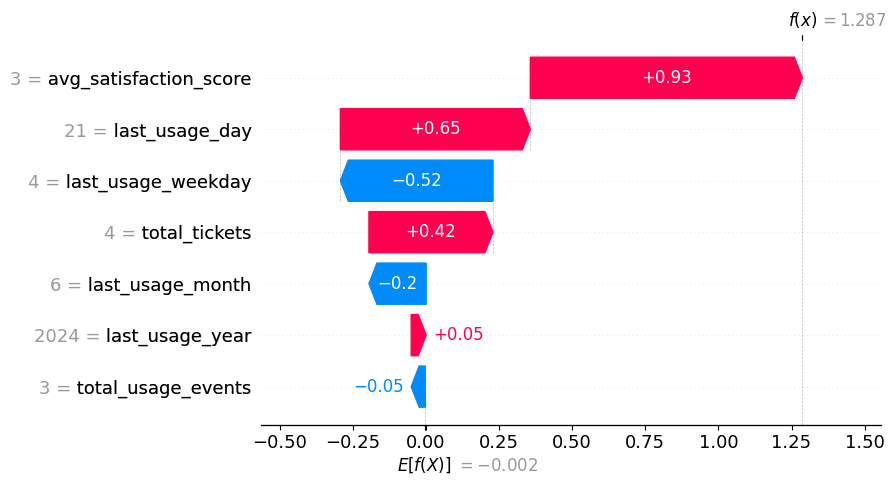

In [27]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("--- Explainable AI (SHAP) ---")

# 1. Initialize the SHAP explainer for our XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values for the test dataset
shap_values = explainer(X_test)

# 3. GLOBAL EXPLANATION: Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Global Feature Drivers")
shap.summary_plot(shap_values, X_test)

# 4. LOCAL EXPLANATION: Waterfall Plot
# Find the indices of customers the model predicted as churners
churn_indices = np.where(y_pred == 1)[0]  # [0] to get the array

if len(churn_indices) > 0:
    # Pick the first churner for local explanation
    first_churner_idx = churn_indices[0]  # single integer index

    print(f"\nGenerating Local Explanation for Test Customer Index: {first_churner_idx}")
    plt.figure(figsize=(10, 6))
    
    # Pass exactly one row to the waterfall plot
    shap.plots.waterfall(shap_values[first_churner_idx])
else:
    print("No churners predicted in the test set to explain.")